## check CMIP calendar styles

In [13]:
from src.forcing import regrid_pcrglobwb_forcing,generate_PCRGLOBWB_CMIP_historical_forcing
from pathlib import Path
import ewatercycle.forcing
import xarray as xr

In [14]:
start_date = "1951-01-02T00:00Z"
end_date = "1957-12-31T00:00Z"


#generate_PCRGLOBWB_CMIP_historical_forcing("AralSea_basin", start = start_date, end = end_date, model= "CanESM5")

In [15]:


directory = Path('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/CMIP6_CanESM5_1951-1957/AralSea_basin/work/diagnostic/script')

print(directory.exists())

True


In [16]:
PCR_CMIP_hist_Forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/CMIP6_CanESM5_1951-1957/AralSea_basin/work/diagnostic/script",
)

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 2920, lat: 8, lon: 10, bnds: 2)
Coordinates:
  * time       (time) object 23kB 1950-01-01 00:00:00 ... 1957-12-31 00:00:00
  * lat        (lat) float32 32B 51.63 48.84 46.05 43.26 40.46 37.67 34.88 32.09
  * lon        (lon) float32 40B 56.25 59.06 61.88 64.69 ... 75.94 78.75 81.56
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 934kB 266.4 263.8 262.6 ... 264.3 255.6
    time_bnds  (time, bnds) object 47kB 1949-12-31 12:00:00 ... 1957-12-31 12...
    lat_bnds   (lat, bnds) float32 64B 53.02 50.23 50.23 ... 33.49 33.49 30.7
    lon_bnds   (lon, bnds) float32 80B 54.84 57.66 57.66 ... 80.16 80.16 82.97
Attributes: (12/52)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conven

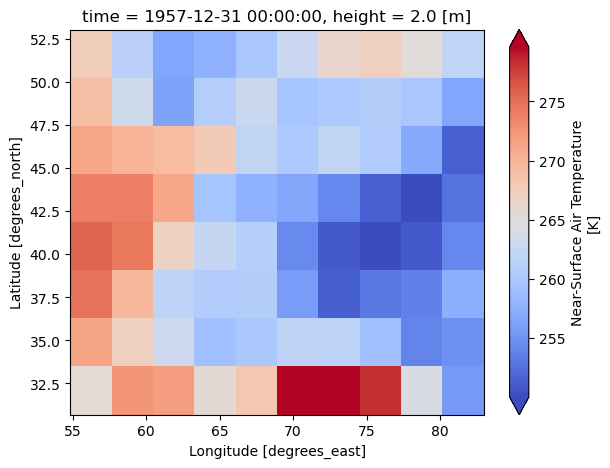

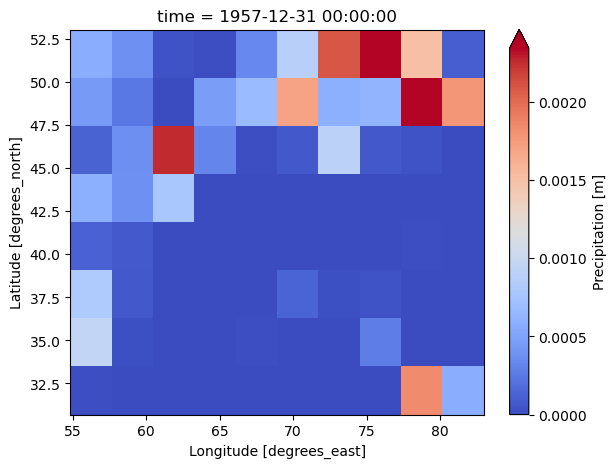

In [17]:
for file_name in [PCR_CMIP_hist_Forcing.temperatureNC, PCR_CMIP_hist_Forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{PCR_CMIP_hist_Forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

In [ ]:
# import pandas as pd

# timeseries_check = dataset["time"].values
# timeseries_check = pd.DatetimeIndex(timeseries_check)
# feb29_dates = timeseries_check[(timeseries_check.month == 2) & (timeseries_check.day == 29)]
# print(feb29_dates)

TypeError: <class 'cftime._cftime.DatetimeNoLeap'> is not convertible to datetime, at position 0

In [19]:
dates = dataset["time"].values
feb29s = [d for d in dates if d.month == 2 and d.day == 29]
print(f"Feb 29 count: {len(feb29s)}")
print(feb29s)

Feb 29 count: 0
[]
